In [196]:
import ROOT
%jsroot off

In [197]:
def getHistogram(f, color):
    h = f.Get("h_count").Clone()
    h.SetLineColor(color)
    h.SetFillColor(color)
    h.GetXaxis().SetRangeUser(1140, 1500)
    return h

In [198]:
def makePlot(h_null, h_aluminum, h_calcium, h_titanium, h_iron, h_copper, name):
    c = ROOT.TCanvas()
    h_null.Draw()
    h_aluminum.Draw("SAME")
    h_calcium.Draw("SAME")
    h_titanium.Draw("SAME")
    h_iron.Draw("SAME")
    h_copper.Draw("SAME")
    h_null.SetTitle(name)
    h_null.GetXaxis().SetTitle("Threshold (DAC)")
    h_null.GetYaxis().SetTitle("Single pixel counts")
    
    legend = ROOT.TLegend(0.65,0.55,0.98,0.75)
    legend.AddEntry(h_aluminum,"Aluminum (1.5 keV)","l")
    legend.AddEntry(h_calcium,"Calcium (3.7 keV)","l")
    legend.AddEntry(h_titanium,"Titanium (4.5 keV)","l")
    legend.AddEntry(h_iron,"Iron (6.4 keV)","l")
    legend.AddEntry(h_copper,"Copper (8.0 keV)","l")
    legend.Draw()
    
    c.Draw()
    c.SaveAs(f"peaks_{name}.png")

In [199]:
def fitHistogram(hist, name, fit_type="full_gaussian", save_plot=False):
    # get fit priors
    constant_prefit = hist.GetMaximum()
    mean_prefit = hist.GetMean()
    stddev_prefit = hist.GetStdDev()
    maximumpos_prefit = hist.GetXaxis().GetBinCenter(hist.GetMaximumBin())

    # fit gaussian
    fit_fcn = ROOT.TF1("fit_fcn", "gaus(0)")
    fit_fcn.SetParameters(constant_prefit,maximumpos_prefit,stddev_prefit)
    if fit_type == "full_gaussian":
        fit_result = hist.Fit(fit_fcn, "isq", "", maximumpos_prefit - 3. * stddev_prefit, maximumpos_prefit + 3. * stddev_prefit)
    if fit_type == "half_gaussian":
        fit_result = hist.Fit(fit_fcn, "isq", "", maximumpos_prefit - 0.05 * stddev_prefit, maximumpos_prefit + 1.5 * stddev_prefit)
    if fit_type == "long_half_gaussian":
        fit_result = hist.Fit(fit_fcn, "isq", "", maximumpos_prefit - 0.01 * stddev_prefit, maximumpos_prefit + 3.0 * stddev_prefit)
    if fit_type == "narrow_gaussian":
        fit_result = hist.Fit(fit_fcn, "isq", "", maximumpos_prefit - 0.3 * stddev_prefit, maximumpos_prefit + 0.3 * stddev_prefit)
    threshold = fit_result.Parameter(1)
    threshold_err = fit_result.ParError(1)

    if save_plot:
        c = ROOT.TCanvas()
        hist.Draw()
        hist.GetXaxis().SetRangeUser(maximumpos_prefit - 5. * stddev_prefit, maximumpos_prefit + 5. * stddev_prefit)
        c.Draw()
        c.SaveAs(f'fit_{name}.png')

    return threshold, threshold_err

## CLICpix2-1185_1_E1

In [200]:
basepath = "results/CLICpix2-1185_1_E1/"
f_null = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_null_totcnt_2ms_10r.root")
h_null = getHistogram(f_null, ROOT.kBlack)

f_aluminum = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_aluminum_totcnt_2ms_10r.root")
h_aluminum = getHistogram(f_aluminum, ROOT.kOrange)

f_calcium = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_calcium_totcnt_2ms_10r.root")
h_calcium = getHistogram(f_calcium, ROOT.kGreen)

f_titanium = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_titanium_totcnt_2ms_10r.root")
h_titanium = getHistogram(f_titanium, ROOT.kMagenta)

f_iron = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_iron_totcnt_2ms_10r.root")
h_iron = getHistogram(f_iron, ROOT.kRed)

f_copper = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_copper_totcnt_2ms_10r.root")
h_copper = getHistogram(f_copper, ROOT.kBlue)

In [201]:
makePlot(h_null, h_aluminum, h_calcium, h_titanium, h_iron, h_copper, name="CLICpix2-1185_1_E1")

Info in <TCanvas::Print>: png file peaks_CLICpix2-1185_1_E1.png has been created


In [202]:
energy = []
threshold = []
threshold_err = []


fit_null = fitHistogram(h_null, "baseline", fit_type="full_gaussian", save_plot=True)
baseline = fit_null[0]
print(f"baseline: {baseline}")

fit_aluminum = fitHistogram(h_aluminum, "aluminum", fit_type="half_gaussian", save_plot=True)
energy.append(1.5)
threshold.append(fit_aluminum[0] - baseline)
threshold_err.append(fit_aluminum[1])

fit_calcium = fitHistogram(h_calcium, "calcium", fit_type="half_gaussian", save_plot=True)
energy.append(3.7)
threshold.append(fit_calcium[0] - baseline)
threshold_err.append(fit_calcium[1])

fit_titanium = fitHistogram(h_titanium, "titanium", fit_type="narrow_gaussian", save_plot=True)
energy.append(4.5)
threshold.append(fit_titanium[0] - baseline)
threshold_err.append(fit_titanium[1])

fit_iron = fitHistogram(h_iron, "iron", fit_type="narrow_gaussian", save_plot=True)
energy.append(6.4)
threshold.append(fit_iron[0] - baseline)
threshold_err.append(fit_iron[1])

fit_copper = fitHistogram(h_copper, "copper", fit_type="narrow_gaussian", save_plot=True)
energy.append(8.0)
threshold.append(fit_copper[0] - baseline)
threshold_err.append(fit_copper[1])

# from IPython.display import Image
# Image("fit_copper.png")

baseline: 1182.2333708685728


Info in <TCanvas::Print>: png file fit_baseline.png has been created
Info in <TCanvas::Print>: png file fit_aluminum.png has been created
Info in <TCanvas::Print>: png file fit_calcium.png has been created
Info in <TCanvas::Print>: png file fit_titanium.png has been created
Info in <TCanvas::Print>: png file fit_iron.png has been created
Info in <TCanvas::Print>: png file fit_copper.png has been created


<ErrorbarContainer object of 3 artists>

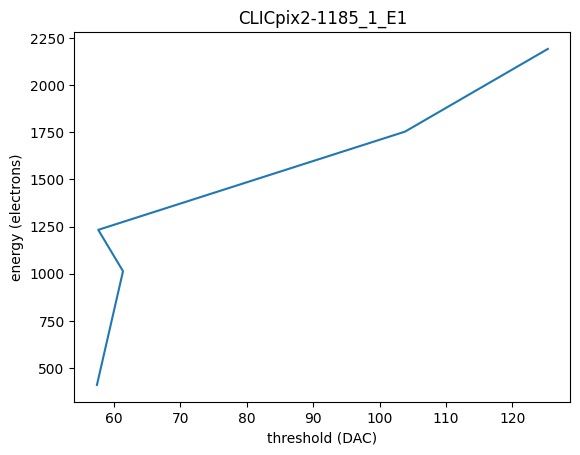

In [203]:
# convert energy from keV to electron counts, assuming 3.65 eV in Si to create electron hole pair
import numpy as np
energy_eh = np.array(energy) / 3.65 * 1000.

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
plt.xlabel('threshold (DAC)')
plt.ylabel('energy (electrons)')
plt.title('CLICpix2-1185_1_E1')
ax.errorbar(threshold, energy_eh)

13.712422286674787


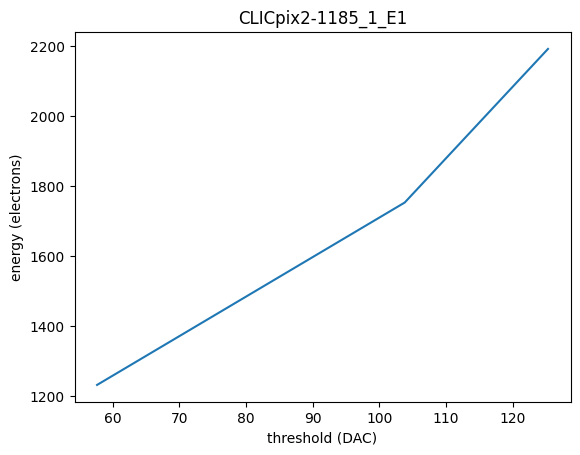

In [204]:
fig, ax = plt.subplots()
plt.xlabel('threshold (DAC)')
plt.ylabel('energy (electrons)')
plt.title('CLICpix2-1185_1_E1')
ax.errorbar(threshold[2:], energy_eh[2:])

import numpy as np
slope, intercept = np.polyfit(threshold[2:], energy_eh[2:], 1)
print(slope)

In [205]:
basepath = "results/CLICpix2-973_1_E1/"
f_null = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_null_totcnt_2ms_10r.root")
h_null = getHistogram(f_null, ROOT.kBlack)

f_aluminum = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_aluminum_totcnt_2ms_10r.root")
h_aluminum = getHistogram(f_aluminum, ROOT.kOrange)

f_calcium = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_calcium_totcnt_2ms_10r.root")
h_calcium = getHistogram(f_calcium, ROOT.kGreen)

f_titanium = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_titanium_totcnt_2ms_10r.root")
h_titanium = getHistogram(f_titanium, ROOT.kMagenta)

f_iron = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_iron_totcnt_2ms_10r.root")
h_iron = getHistogram(f_iron, ROOT.kRed)

f_copper = ROOT.TFile.Open(basepath + "sourceTHLscan_plots_copper_totcnt_2ms_10r.root")
h_copper = getHistogram(f_copper, ROOT.kBlue)

In [206]:
makePlot(h_null, h_aluminum, h_calcium, h_titanium, h_iron, h_copper, name="CLICpix2-973_1_E1")

Info in <TCanvas::Print>: png file peaks_CLICpix2-973_1_E1.png has been created


baseline: 1225.866045339376


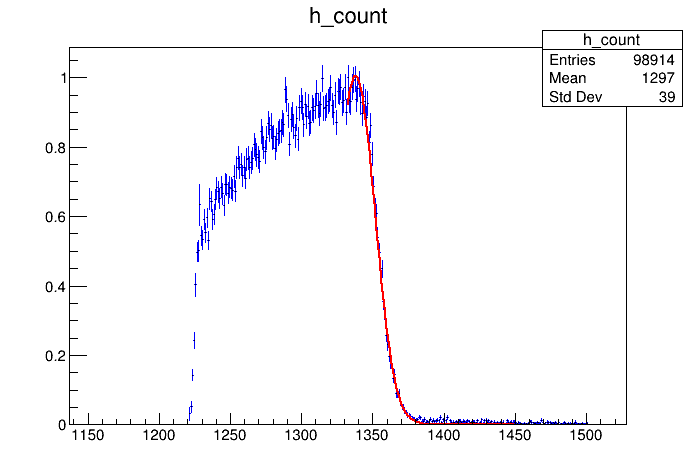

Info in <TCanvas::Print>: png file fit_baseline.png has been created
Info in <TCanvas::Print>: png file fit_aluminum.png has been created
Info in <TCanvas::Print>: png file fit_calcium.png has been created
Info in <TCanvas::Print>: png file fit_titanium.png has been created
Info in <TCanvas::Print>: png file fit_iron.png has been created
Info in <TCanvas::Print>: png file fit_copper.png has been created


In [207]:
energy = []
threshold = []
threshold_err = []


fit_null = fitHistogram(h_null, "baseline", fit_type="full_gaussian", save_plot=True)
baseline = fit_null[0]
print(f"baseline: {baseline}")

fit_aluminum = fitHistogram(h_aluminum, "aluminum", fit_type="long_half_gaussian", save_plot=True)
energy.append(1.5)
threshold.append(fit_aluminum[0] - baseline)
threshold_err.append(fit_aluminum[1])

fit_calcium = fitHistogram(h_calcium, "calcium", fit_type="long_half_gaussian", save_plot=True)
energy.append(3.7)
threshold.append(fit_calcium[0] - baseline)
threshold_err.append(fit_calcium[1])

fit_titanium = fitHistogram(h_titanium, "titanium", fit_type="narrow_gaussian", save_plot=True)
energy.append(4.5)
threshold.append(fit_titanium[0] - baseline)
threshold_err.append(fit_titanium[1])

fit_iron = fitHistogram(h_iron, "iron", fit_type="narrow_gaussian", save_plot=True)
energy.append(6.4)
threshold.append(fit_iron[0] - baseline)
threshold_err.append(fit_iron[1])

fit_copper = fitHistogram(h_copper, "copper", fit_type="long_half_gaussian", save_plot=True)
energy.append(8.0)
threshold.append(fit_copper[0] - baseline)
threshold_err.append(fit_copper[1])

from IPython.display import Image
Image("fit_copper.png")

<ErrorbarContainer object of 3 artists>

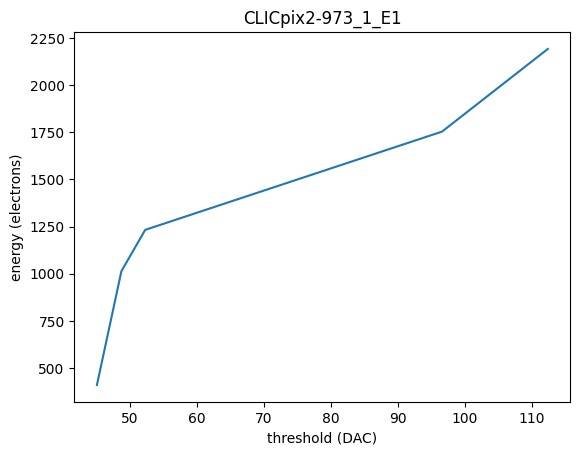

In [208]:
# convert energy to electron counts
import numpy as np
energy_eh = np.array(energy) / 3.65 * 1000.

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
plt.xlabel('threshold (DAC)')
plt.ylabel('energy (electrons)')
plt.title('CLICpix2-973_1_E1')
ax.errorbar(threshold, energy_eh)

15.027841627005945


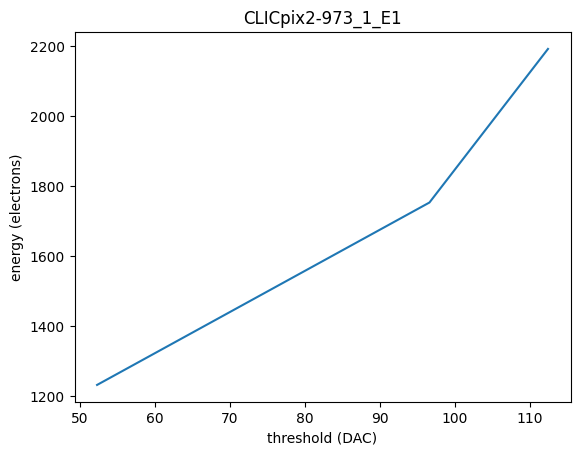

In [209]:
fig, ax = plt.subplots()
plt.xlabel('threshold (DAC)')
plt.ylabel('energy (electrons)')
plt.title('CLICpix2-973_1_E1')
ax.errorbar(threshold[2:], energy_eh[2:])

import numpy as np
slope, intercept = np.polyfit(threshold[2:], energy_eh[2:], 1)
print(slope)